EF block
├── ΔN2
├── ΔP3/LPP
└── Nogo|Go PSD
    └── 4 bands × 6 ROIs

ToM block
├── ΔLPC cognitive
├── ΔLPC affective
├── Δearly-LSW cognitive/affective
├── Δmid-LSW cognitive/affective
├── Δlate-LSW cognitive/affective
└── False|True PSD
    └── 4 bands × 6 ROIs

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

BASE = Path(r"H:\ASD projoect")

ASD = pd.read_csv(
    BASE / "ASD_Pearson_features.csv"
)

TD = pd.read_csv(
    BASE / "TD_Pearson_features.csv"
)

ASD["group"] = "ASD"
TD["group"] = "TD"

ALL = pd.concat(
    [ASD, TD],
    ignore_index=True
)

print("ASD:", len(ASD))
print("TD:", len(TD))
print("Total:", len(ALL))

ASD: 33
TD: 29
Total: 62


In [6]:
BANDS = [
    "theta",
    "alpha",
    "low_beta",
    "beta"
]

ROIS = [
    "frontal",
    "frontocentral",
    "central",
    "centroparietal",
    "parietal",
    "posterior"
]

In [7]:
def center_condition(df, prefix, condition):

    df = df.copy()

    for band in BANDS:

        cols = [
            f"{prefix}_{condition}_{band}_{roi}_PSD_dB"
            for roi in ROIS
        ]

        available = [
            c for c in cols
            if c in df.columns
        ]

        global_mean = df[available].mean(
            axis=1
        )

        for roi in ROIS:

            col = (
                f"{prefix}_{condition}_"
                f"{band}_{roi}_PSD_dB"
            )

            if col not in df.columns:
                continue

            df[
                f"{prefix}_{condition}_"
                f"{band}_{roi}_centered"
            ] = (
                df[col]
                - global_mean
            )

    return df

In [8]:
def residualize(target, control):

    target = pd.to_numeric(
        target,
        errors="coerce"
    )

    control = pd.to_numeric(
        control,
        errors="coerce"
    )

    valid = (
        target.notna()
        & control.notna()
    )

    result = pd.Series(
        np.nan,
        index=target.index
    )

    if valid.sum() < 4:
        return result

    x = control[valid].to_numpy()
    y = target[valid].to_numpy()

    slope, intercept = np.polyfit(
        x,
        y,
        1
    )

    result.loc[valid] = (
        y
        - (intercept + slope * x)
    )

    return result

In [9]:
def make_specific_psd(df):

    df = df.copy()

    # Center EF
    for condition in ["go", "nogo"]:

        df = center_condition(
            df,
            "EF",
            condition
        )

    # Center ToM
    for segment in ["H", "T"]:

        for condition in [
            "false_cog",
            "true_cog",
            "false_aff",
            "true_aff"
        ]:

            df = center_condition(
                df,
                segment,
                condition
            )

    # EF: Nogo controlling Go
    for band in BANDS:

        for roi in ROIS:

            df[
                f"EF_specific_{band}_{roi}"
            ] = residualize(

                df[
                    f"EF_nogo_{band}_{roi}_centered"
                ],

                df[
                    f"EF_go_{band}_{roi}_centered"
                ]
            )

    # ToM: False controlling True
    for segment in ["H", "T"]:

        for domain in ["cog", "aff"]:

            for band in BANDS:

                for roi in ROIS:

                    df[
                        f"{segment}_specific_"
                        f"{domain}_{band}_{roi}"
                    ] = residualize(

                        df[
                            f"{segment}_false_{domain}_"
                            f"{band}_{roi}_centered"
                        ],

                        df[
                            f"{segment}_true_{domain}_"
                            f"{band}_{roi}_centered"
                        ]
                    )

    return df

In [10]:
ASD = make_specific_psd(ASD)
TD = make_specific_psd(TD)

ALL = pd.concat(
    [ASD, TD],
    ignore_index=True
)

In [11]:
def remove_group_mean(df, columns):

    out = df[columns].copy()

    for col in columns:

        out[col] = (
            df[col]
            - df.groupby("group")[col].transform(
                "mean"
            )
        )

    return out

In [12]:
EF_PSD = [
    f"EF_specific_{band}_{roi}"
    for band in BANDS
    for roi in ROIS
]

In [14]:
def tom_psd_cols(
    segment,
    domain
):

    return [
        f"{segment}_specific_"
        f"{domain}_{band}_{roi}"

        for band in BANDS
        for roi in ROIS
    ]

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import CCA
from scipy.stats import pearsonr

import numpy as np
import pandas as pd

In [2]:
def pca_cca(
    df,
    x_cols,
    y_cols,
    n_pc_x=4,
    n_pc_y=4
):

    use_cols = (
        ["group"]
        + x_cols
        + y_cols
    )

    data = (
        df[use_cols]
        .dropna()
        .reset_index(drop=True)
    )

    # -------------------------
    # remove group means
    # -------------------------
    X = remove_group_mean(
        data,
        x_cols
    )

    Y = remove_group_mean(
        data,
        y_cols
    )

    # -------------------------
    # standardize
    # -------------------------
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()

    Xz = scaler_x.fit_transform(X)
    Yz = scaler_y.fit_transform(Y)

    # -------------------------
    # PCA
    # -------------------------
    pca_x = PCA(
        n_components=n_pc_x
    )

    pca_y = PCA(
        n_components=n_pc_y
    )

    Xp = pca_x.fit_transform(Xz)
    Yp = pca_y.fit_transform(Yz)

    # -------------------------
    # CCA
    # -------------------------
    cca = CCA(
        n_components=1,
        max_iter=5000
    )

    Xc, Yc = cca.fit_transform(
        Xp,
        Yp
    )

    r, _ = pearsonr(
        Xc[:, 0],
        Yc[:, 0]
    )

    return {
        "data": data,

        "X": Xz,
        "Y": Yz,

        "Xp": Xp,
        "Yp": Yp,

        "pca_x": pca_x,
        "pca_y": pca_y,
        "cca": cca,

        "x_score": Xc[:, 0],
        "y_score": Yc[:, 0],

        "canonical_r": r,

        "x_cols": x_cols,
        "y_cols": y_cols
    }

In [15]:
CCA_H_cog = pca_cca(
    ALL,
    EF_PSD,
    tom_psd_cols(
        "H",
        "cog"
    ),
    n_pc_x=4,
    n_pc_y=4
)

print(
    "EF variance retained:",
    CCA_H_cog["pca_x"]
    .explained_variance_ratio_
    .sum()
)

print(
    "ToM variance retained:",
    CCA_H_cog["pca_y"]
    .explained_variance_ratio_
    .sum()
)

print(
    "Canonical r:",
    CCA_H_cog["canonical_r"]
)

EF variance retained: 0.5318113963819759
ToM variance retained: 0.5906901343124673
Canonical r: 0.6337074136651901


In [16]:
def permutation_pca_cca(
    result,
    n_perm=5000,
    random_state=42
):

    rng = np.random.default_rng(
        random_state
    )

    Xp = result["Xp"]
    Yp = result["Yp"]

    groups = (
        result["data"]["group"]
        .to_numpy()
    )

    observed = abs(
        result["canonical_r"]
    )

    perm_r = []

    for _ in range(n_perm):

        Y_perm = Yp.copy()

        # shuffle ToM subjects within group
        for group in np.unique(groups):

            idx = np.where(
                groups == group
            )[0]

            shuffled = rng.permutation(
                idx
            )

            Y_perm[idx] = Yp[
                shuffled
            ]

        cca = CCA(
            n_components=1,
            max_iter=5000
        )

        Xc, Yc = cca.fit_transform(
            Xp,
            Y_perm
        )

        r, _ = pearsonr(
            Xc[:, 0],
            Yc[:, 0]
        )

        perm_r.append(
            abs(r)
        )

    perm_r = np.array(
        perm_r
    )

    p_perm = (
        1
        + np.sum(
            perm_r >= observed
        )
    ) / (
        n_perm + 1
    )

    return p_perm, perm_r

In [17]:
p_perm, cca_null = permutation_pca_cca(
    CCA_H_cog,
    n_perm=5000
)

print(
    "Canonical r:",
    CCA_H_cog["canonical_r"]
)

print(
    "Permutation p:",
    p_perm
)

Canonical r: 0.6337074136651901
Permutation p: 0.0007998400319936012


# cross-validation

In [18]:
from sklearn.model_selection import KFold

In [19]:
def cross_validated_pca_cca(
    df,
    x_cols,
    y_cols,
    n_pc_x=4,
    n_pc_y=4,
    n_splits=5,
    random_state=42
):

    data = (
        df[
            ["group"]
            + x_cols
            + y_cols
        ]
        .dropna()
        .reset_index(drop=True)
    )

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    x_test_scores = []
    y_test_scores = []

    for train_idx, test_idx in kf.split(data):

        train = data.iloc[
            train_idx
        ].copy()

        test = data.iloc[
            test_idx
        ].copy()

        # ----------------------
        # group mean adjustment
        # based on TRAIN only
        # ----------------------

        X_train = train[x_cols].copy()
        Y_train = train[y_cols].copy()

        X_test = test[x_cols].copy()
        Y_test = test[y_cols].copy()

        for col in x_cols:

            group_means = (
                train
                .groupby("group")[col]
                .mean()
            )

            X_train[col] = (
                train[col]
                - train["group"].map(
                    group_means
                )
            )

            X_test[col] = (
                test[col]
                - test["group"].map(
                    group_means
                )
            )

        for col in y_cols:

            group_means = (
                train
                .groupby("group")[col]
                .mean()
            )

            Y_train[col] = (
                train[col]
                - train["group"].map(
                    group_means
                )
            )

            Y_test[col] = (
                test[col]
                - test["group"].map(
                    group_means
                )
            )

        # standardize
        sx = StandardScaler()
        sy = StandardScaler()

        X_train = sx.fit_transform(
            X_train
        )

        X_test = sx.transform(
            X_test
        )

        Y_train = sy.fit_transform(
            Y_train
        )

        Y_test = sy.transform(
            Y_test
        )

        # PCA
        px = PCA(
            n_components=n_pc_x
        )

        py = PCA(
            n_components=n_pc_y
        )

        X_train = px.fit_transform(
            X_train
        )

        X_test = px.transform(
            X_test
        )

        Y_train = py.fit_transform(
            Y_train
        )

        Y_test = py.transform(
            Y_test
        )

        # CCA
        cca = CCA(
            n_components=1,
            max_iter=5000
        )

        cca.fit(
            X_train,
            Y_train
        )

        Xc, Yc = cca.transform(
            X_test,
            Y_test
        )

        x_test_scores.extend(
            Xc[:, 0]
        )

        y_test_scores.extend(
            Yc[:, 0]
        )

    r_cv, p_cv = pearsonr(
        x_test_scores,
        y_test_scores
    )

    return r_cv, p_cv

In [20]:
for seed in [
    1,
    10,
    42,
    100,
    2026
]:

    r_cv, _ = cross_validated_pca_cca(
        ALL,
        EF_PSD,
        tom_psd_cols(
            "H",
            "cog"
        ),
        random_state=seed
    )

    print(
        seed,
        round(r_cv, 3)
    )

1 0.375
10 0.321
42 0.361
100 0.504
2026 0.323


In [21]:
CCA_RESULTS = []

for segment in [
    "H",
    "T"
]:

    for domain in [
        "cog",
        "aff"
    ]:

        result = pca_cca(
            ALL,
            EF_PSD,
            tom_psd_cols(
                segment,
                domain
            )
        )

        p_perm, _ = permutation_pca_cca(
            result,
            n_perm=5000
        )

        cv_values = []

        for seed in [
            1,
            10,
            42,
            100,
            2026
        ]:

            r_cv, _ = (
                cross_validated_pca_cca(
                    ALL,
                    EF_PSD,
                    tom_psd_cols(
                        segment,
                        domain
                    ),
                    random_state=seed
                )
            )

            cv_values.append(
                r_cv
            )

        CCA_RESULTS.append({
            "segment": segment,
            "domain": domain,
            "n": len(
                result["data"]
            ),

            "canonical_r":
                result["canonical_r"],

            "permutation_p":
                p_perm,

            "CV_r_mean":
                np.mean(
                    cv_values
                ),

            "CV_r_min":
                np.min(
                    cv_values
                ),

            "CV_r_max":
                np.max(
                    cv_values
                )
        })

In [22]:
CCA_summary = pd.DataFrame(
    CCA_RESULTS
)

display(
    CCA_summary
)

,segment,domain,n,canonical_r,permutation_p,CV_r_mean,CV_r_min,CV_r_max
0,H,cog,62,0.633707,0.000800,0.376487,0.320682,0.503871
1,H,aff,62,0.439464,0.278344,0.044232,-0.030553,0.210464
2,T,cog,62,0.453885,0.222156,0.042197,-0.037714,0.128373
3,T,aff,62,0.426025,0.358928,-0.257876,-0.319908,-0.136674


.0008 ->FDR-> .0032

# Plots

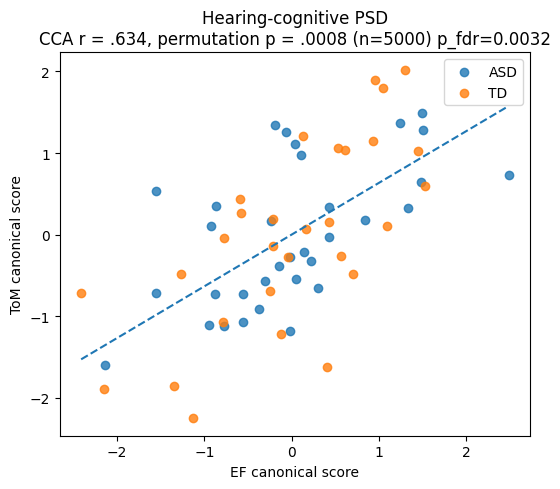

In [25]:
import matplotlib.pyplot as plt
import numpy as np

result = CCA_H_cog

x = result["x_score"]
y = result["y_score"]
groups = result["data"]["group"].values

fig, ax = plt.subplots(figsize=(5.5, 5))

for group in ["ASD", "TD"]:
    mask = groups == group

    ax.scatter(
        x[mask],
        y[mask],
        alpha=0.8,
        label=group
    )

# overall regression line
coef = np.polyfit(x, y, 1)
xx = np.linspace(x.min(), x.max(), 100)

ax.plot(
    xx,
    coef[0] * xx + coef[1],
    linestyle="--"
)

ax.set_xlabel("EF canonical score")
ax.set_ylabel("ToM canonical score")
ax.set_title(
    "Hearing-cognitive PSD\n"
    "CCA r = .634, permutation p = .0008 (n=5000) p_fdr=0.0032"
)

ax.legend()
plt.tight_layout()
plt.show()

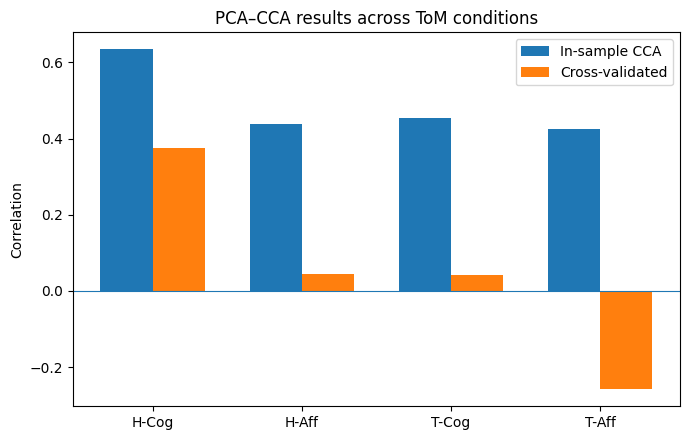

In [24]:
labels = [
    "H-Cog",
    "H-Aff",
    "T-Cog",
    "T-Aff"
]

canonical_r = [
    0.634,
    0.439,
    0.454,
    0.426
]

cv_r = [
    0.376,
    0.044,
    0.042,
    -0.258
]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.bar(
    x - width/2,
    canonical_r,
    width,
    label="In-sample CCA"
)

ax.bar(
    x + width/2,
    cv_r,
    width,
    label="Cross-validated"
)

ax.axhline(0, linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Correlation")
ax.set_title("PCA–CCA results across ToM conditions")
ax.legend()

plt.tight_layout()
plt.show()